In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
#Task 1 — Data Loading & Exploration

In [5]:
df = pd.read_csv("Housing.csv")
print("Dataset Loaded Successfully")
print("First 10 Rows")
df.head(10)

Dataset Loaded Successfully
First 10 Rows


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [35]:
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 545 rows × 13 columns


In [23]:
print("Columns:")
for col, dtype in df.dtypes.items():
    print(f"{col:<30} {dtype}")

Columns:
price                          int64
area                           int64
bedrooms                       int64
bathrooms                      int64
stories                        int64
mainroad                       object
guestroom                      object
basement                       object
hotwaterheating                object
airconditioning                object
parking                        int64
prefarea                       object
furnishingstatus               object


In [25]:
print("Target Column")
print("price")
print("\nFeature Columns")
print(df.drop("price", axis=1).columns)

Target Column
price

Feature Columns
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [27]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
#Task 2 — Data Cleaning

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [39]:
df = df.drop_duplicates()
print("Duplicates Removed")
print(df.shape)

Duplicates Removed
(545, 13)


In [41]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:

            df[col].fillna(df[col].median(), inplace=True)

print("Missing Values Handled")

Missing Values Handled


In [43]:
categorical_columns = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)
print("Categorical Columns Converted")

Categorical Columns Converted


In [56]:
df.head()
print("Descriptive Statistics:\n")
display(df.describe())

print("\nTarget Variable: 'price'")
print(f"   Min: {df['price'].min():,.0f}")
print(f"   Max: {df['price'].max():,.0f}")
print(f"   Mean: {df['price'].mean():,.0f}")
print(f"   Median: {df['price'].median():,.0f}")

Descriptive Statistics:



,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



Target Variable: 'price'
   Min: 1,750,000
   Max: 13,300,000
   Mean: 4,766,729
   Median: 4,340,000


In [ ]:
#Task 3 — Model Building

In [60]:
X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Shape")
print(X_train.shape)
print("\nTesting Shape")
print(X_test.shape)

Training Shape
(436, 13)

Testing Shape
(109, 13)


In [68]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [70]:
linear_predictions = linear_model.predict(X_test)

In [72]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)
print("Linear Regression Results")
print("MAE :", linear_mae)
print("RMSE :", linear_rmse)
print("R2 Score :", linear_r2)

Linear Regression Results
MAE : 970043.403920164
RMSE : 1324506.9600914388
R2 Score : 0.6529242642153184


In [80]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [82]:
rf_predictions = rf_model.predict(
    X_test
)

In [84]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)
print("Random Forest Results")

print("MAE :", rf_mae)

print("RMSE :", rf_rmse)

print("R2 Score :", rf_r2)

Random Forest Results
MAE : 1021546.0353211008
RMSE : 1400565.9728553821
R2 Score : 0.611918531405699


In [88]:
comparison = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Random Forest"
        ],

        "MAE": [
            linear_mae,
            rf_mae
        ],

        "RMSE": [
            linear_rmse,
            rf_rmse
        ],

        "R2 Score": [
            linear_r2,
            rf_r2
        ]
    }
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [ ]:
#Task 4 — Visualization

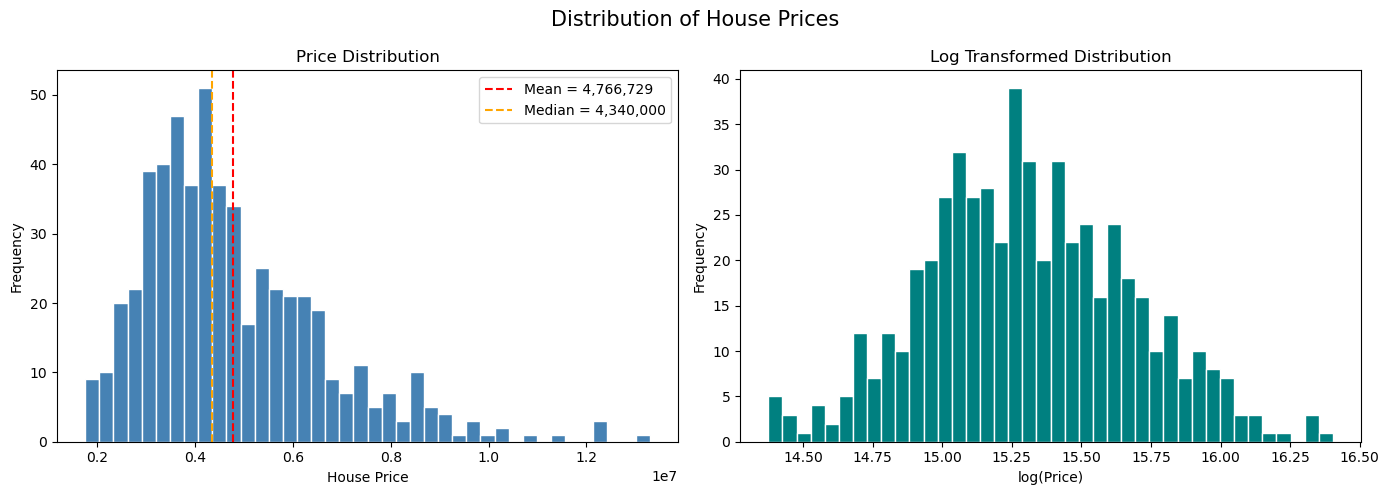

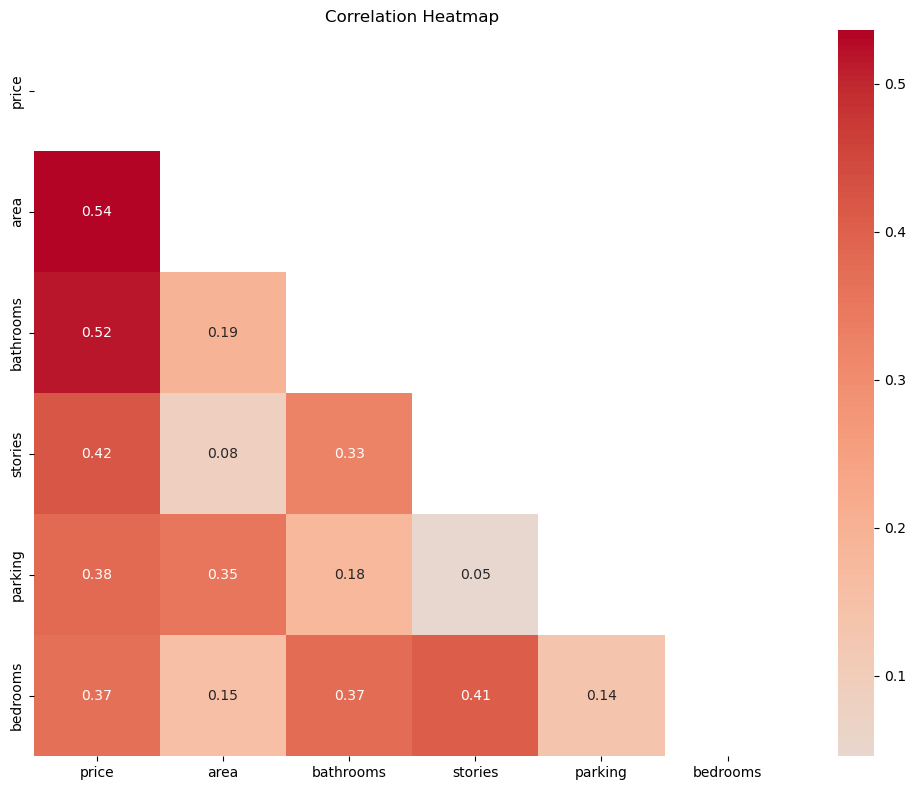

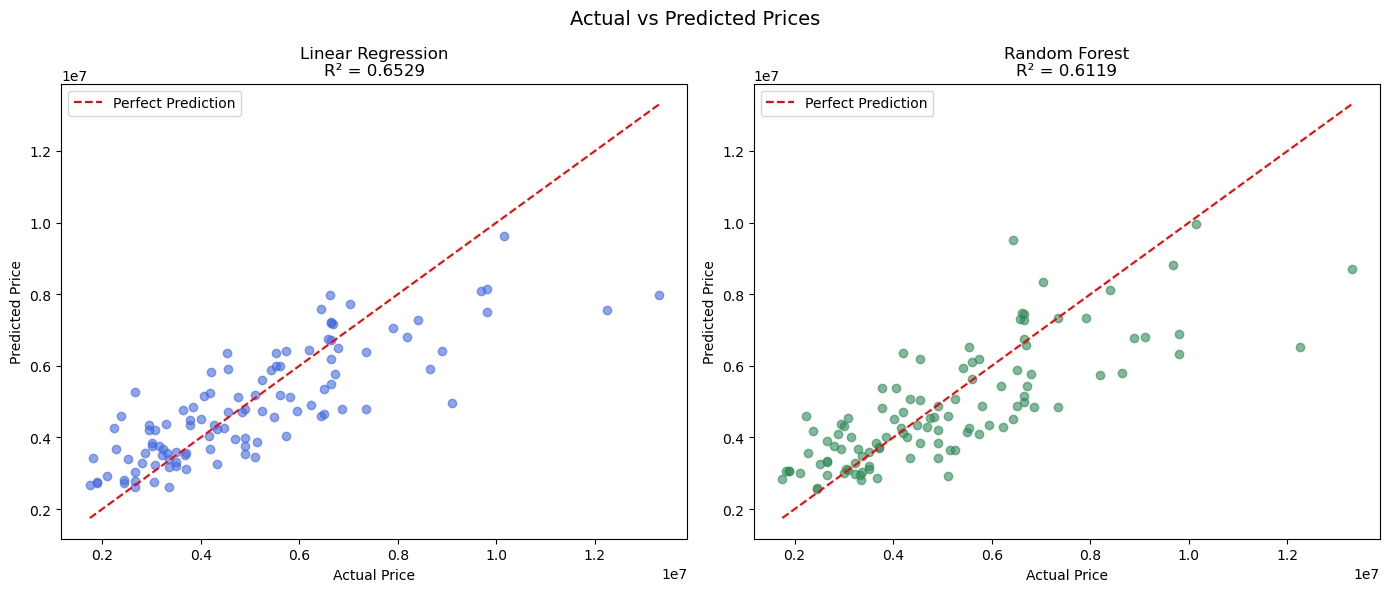

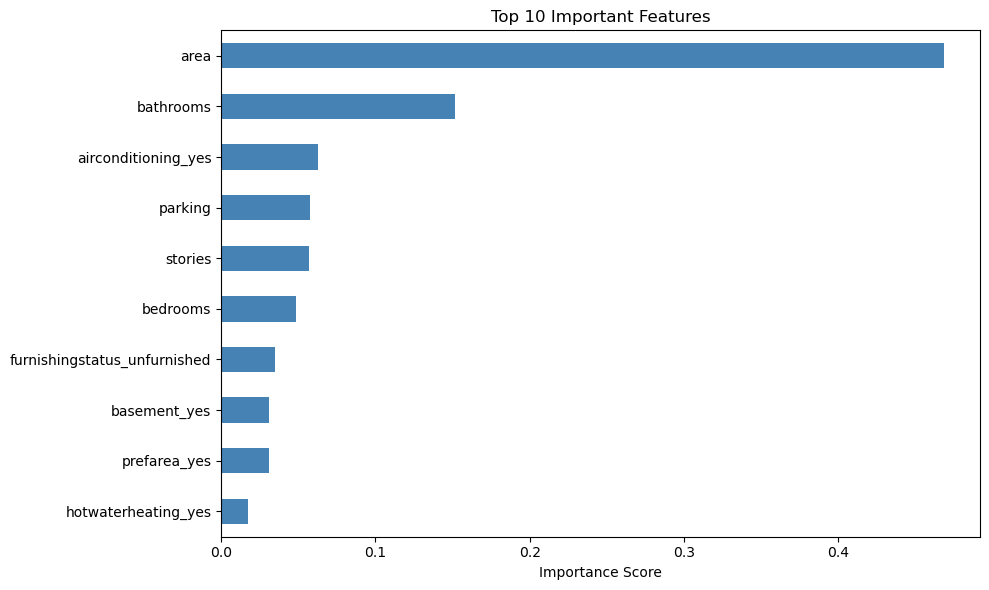

Charts saved successfully.


In [101]:
import seaborn as sns

chart_path = "charts"
os.makedirs(chart_path, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of House Prices", fontsize=15)

axes[0].hist(
    df["price"],
    bins=40,
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("House Price")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    df["price"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df['price'].mean():,.0f}"
)
axes[0].axvline(
    df["price"].median(),
    color="orange",
    linestyle="--",
    label=f"Median = {df['price'].median():,.0f}"
)
axes[0].legend()
log_prices = np.log1p(df["price"])
axes[1].hist(
    log_prices,
    bins=40,
    color="teal",
    edgecolor="white"
)

axes[1].set_title("Log Transformed Distribution")
axes[1].set_xlabel("log(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(chart_path, "price_distribution.png"), dpi=150)
plt.show()
corr_matrix = df.select_dtypes(include="number").corr()
top_features = (
    corr_matrix["price"]
    .abs()
    .sort_values(ascending=False)
    .head(11)
    .index
)
corr_top = df[top_features].corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(
    corr_top,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(chart_path, "correlation_heatmap.png"), dpi=150)
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted Prices", fontsize=14)
models = [
    ("Linear Regression", linear_predictions, "royalblue"),
    ("Random Forest", rf_predictions, "seagreen")
]
for ax, (name, predictions, color) in zip(axes, models):
    score = r2_score(y_test, predictions)
    ax.scatter(
        y_test,
        predictions,
        alpha=0.6,
        color=color
    )

    min_value = min(y_test.min(), predictions.min())
    max_value = max(y_test.max(), predictions.max())
    ax.plot(
        [min_value, max_value],
        [min_value, max_value],
        "r--",
        label="Perfect Prediction"
    )
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{name}\nR² = {score:.4f}")
    ax.legend()
    
plt.tight_layout()
plt.savefig(
    os.path.join(chart_path, "actual_vs_predicted.png"),
    dpi=150
)
plt.show()


feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)
top_features = feature_importance.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(
    kind="barh",
    color="steelblue"
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(
    os.path.join(chart_path, "feature_importance.png"),
    dpi=150
)
plt.show()
print("Charts saved successfully.")

In [ ]:
#Task 5 — Insights & Summary

In [ ]:
'''1. Which features influence house price the most?

The features that have the strongest impact on house prices are area, number of bathrooms, parking spaces, and whether the property is in a preferred location. Houses with larger living areas and better amenities generally have higher prices.

2. How accurate was your model (in plain terms)?

The Linear Regression model achieved an R² score of about 0.65. In simple terms, the model can explain around 65% of the changes in house prices, making its predictions reasonably accurate but not perfect.

3. What surprised you in the data?

A surprising finding was that the Linear Regression model outperformed the Random Forest model. Usually, more complex models perform better, but in this dataset, a simpler model provided more accurate predictions.

4. One recommendation for a real estate business based on your findings

Real estate businesses should focus on promoting properties with larger areas, more bathrooms, sufficient parking, and locations in preferred neighborhoods, as these factors have the greatest influence on property prices and buyer demand.

In [ ]:
One thing I learned while working on my House Price Prediction project:

Before I touched the dataset, I asked myself 3 things:

1. What business decision does this answer?
️2. Why this data — and not something else?
3️. Can I explain my findings in one sentence to someone non-technical?

Those three questions guided everything I did.
From understanding the housing data, to selecting features, to building and comparing machine learning models.
Instead of focusing only on model accuracy, I focused on finding insights that could help buyers, sellers, and real estate businesses make better decisions.

The result?
A project that wasn't just about predicting house prices—it was about understanding what drives them.
And honestly, that's how I approach every data project now.
Data first. Models second. Insights always. 
